In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
sys.path.append("./src")

from utils import *

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime.fake_provider import FakeWashingtonV2, FakeAthensV2

from matplotlib import pyplot as plt
import sys
import numpy as np
from qiskit.quantum_info import Pauli, Statevector
from qiskit_aer.noise import NoiseModel, pauli_error
from qiskit.visualization import plot_gate_map
from qiskit.transpiler import CouplingMap

import pickle


sys.path.append("../../pauli_lindblad_per/")
from tomography.experiment import SparsePauliTomographyExperiment as tomography

plt.style.use("ggplot")

Initial Error: 0.10484684299231518
Exakte Energie:  -7.819890870294844
Optimierte Parameter: [-3.14159265 -1.57070024  1.57082404]
Minimaler Fehler: 0.10484684938626751


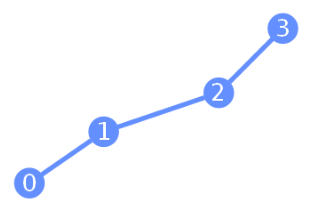

In [3]:
coupling = CouplingMap(couplinglist=[(0, 1), (1, 2), (2, 3)])
backend = GenericBackendV2(num_qubits=4, coupling_map=coupling)

num_qubits, coupling_map = get_backend_info(backend)
plot_gate_map(backend)

hx = 1
hz = 1
J= -1
H_sparse = build_sparse_hamiltonian(hx, hz, backend, J=J)

best_guess, energy_exact = find_best_initial_params(H_sparse, backend)

opt_params, min_error = optimize_energy(best_guess, H_sparse, backend, energy_exact)

expectation_values, paulis = compute_individual_expectation_values(opt_params, backend, hx, hz,J=J, num_layers=1)

print(f"Initial Error: {compute_error(best_guess, H_sparse, backend, energy_exact, num_layers=1)}")
print("Exakte Energie: ", energy_exact)
print("Optimierte Parameter:", opt_params)
print("Minimaler Fehler:", min_error)

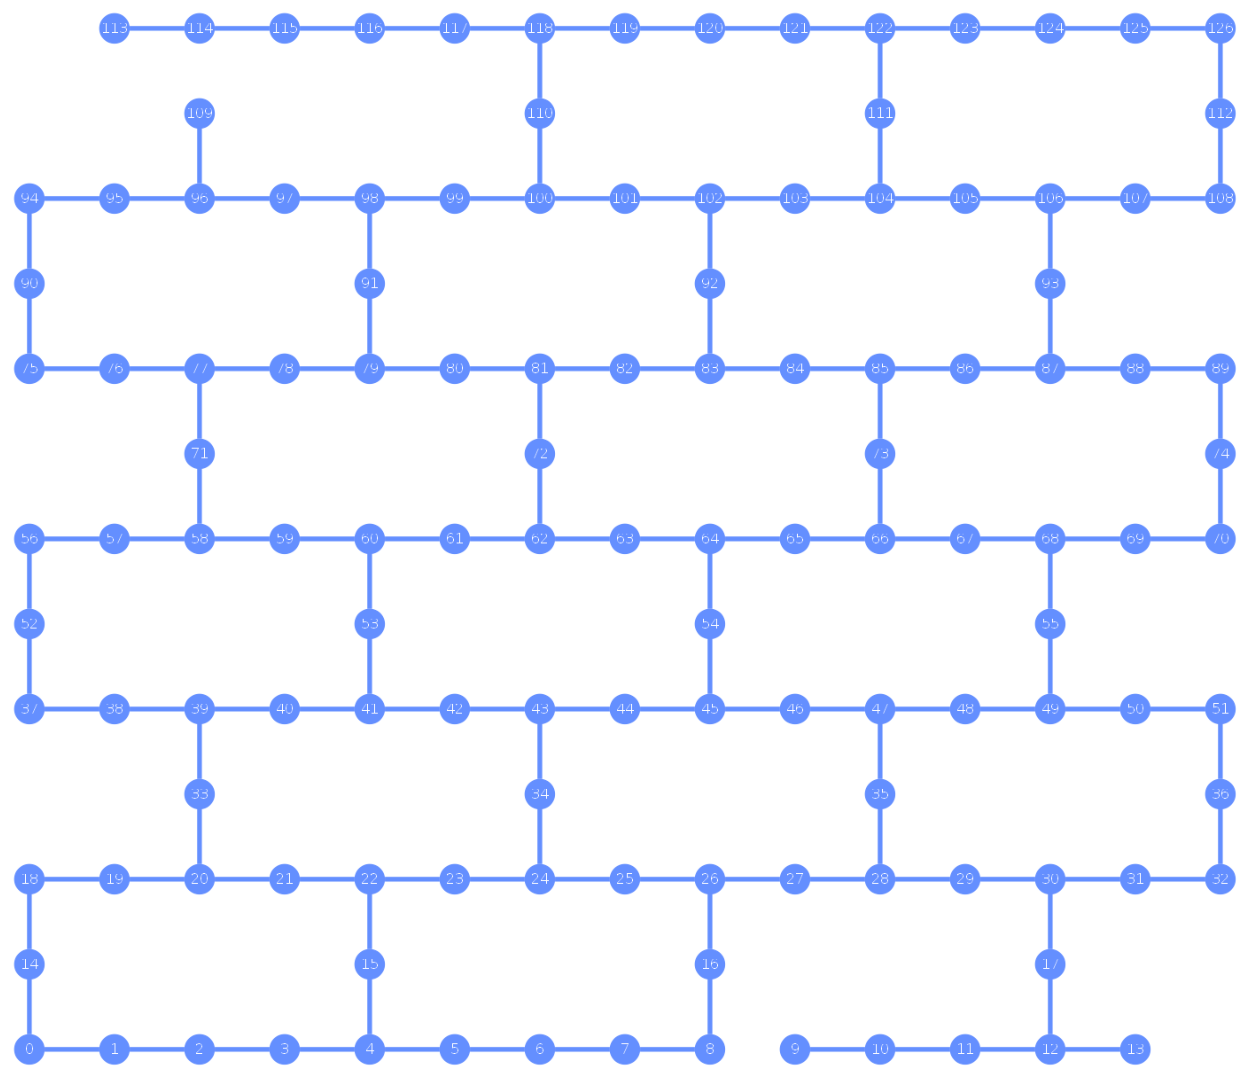

In [3]:
backend = FakeWashingtonV2()
plot_gate_map(backend)
"""coupling_list = backend.configuration().coupling_map
print("Coupling Map:", coupling_list)"""

noise_model = NoiseModel.from_backend(backend)
simulator = AerSimulator.from_backend(backend)

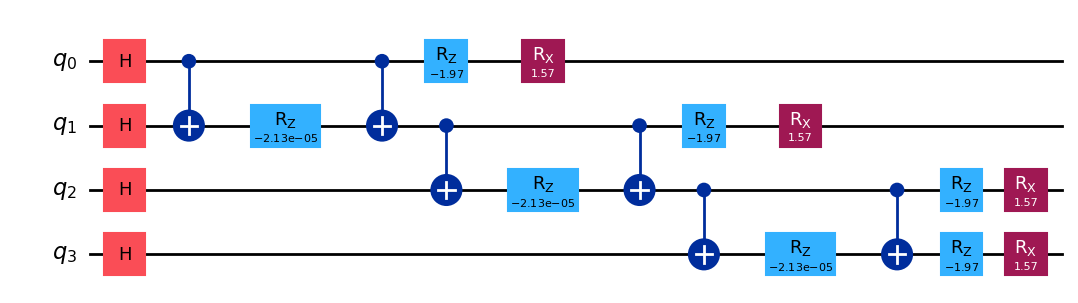

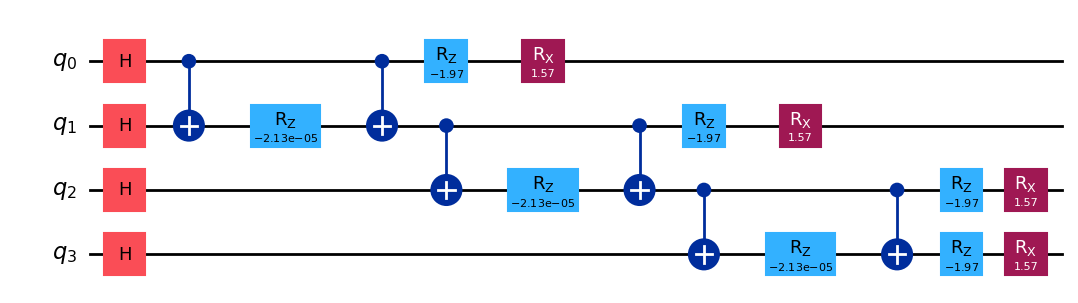

In [4]:
inst_map = [0,1,2,3]
qc = build_hva_layers(opt_params, backend, qubit_indices=inst_map, num_layers=1)

qc.draw('mpl')

In [5]:
experiment = tomography(
    circuits = [qc], #list of circuits from which to get the layers requiring tomography
    inst_map = inst_map, #which physical qubits on the processor to map the qubits in the circuit
    backend = backend, #quantum backend
    used_qubits= inst_map
    )

experiment.generate(
    samples = 100, #Number of samples to take from the fidelity pair measurements
    single_samples = 250, #samples to take from the pair-breaking measurements
    depths = [2,4,16,32,64] #values of 2n to make the pair measurements. Numbers must be even and non-zero
    )

shots = 1024
def executor(circuits):
    return backend.run(circuits, shots = shots, noise_model=noise_model).result().get_counts()

#run the experiment
experiment.run(executor)
noisedataframe = experiment.analyze()

In [6]:
"""with open("Experiment.pkl", "rb") as f:
    experiment = pickle.load(f)"""
    
    
with open("Experiment.pkl", "wb") as f:
    pickle.dump(experiment, f)

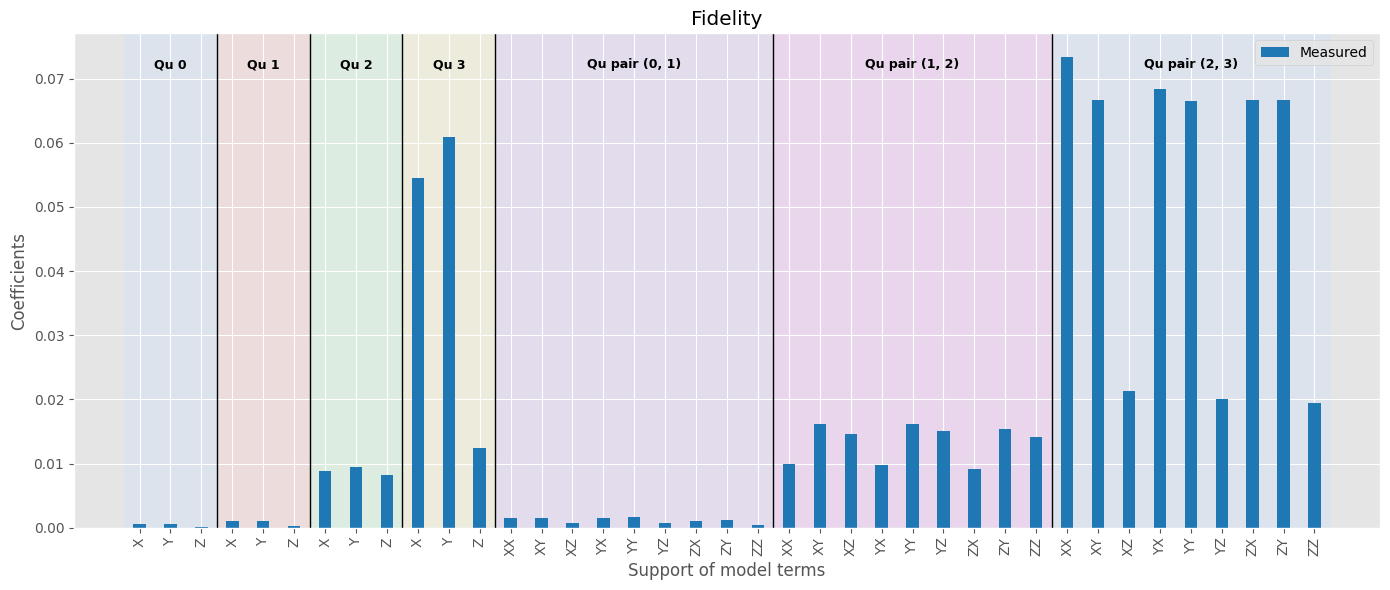

In [7]:
layer = experiment.analysis.get_layer_data(0)
layer.plot_infidelitites(plot_style = 2)

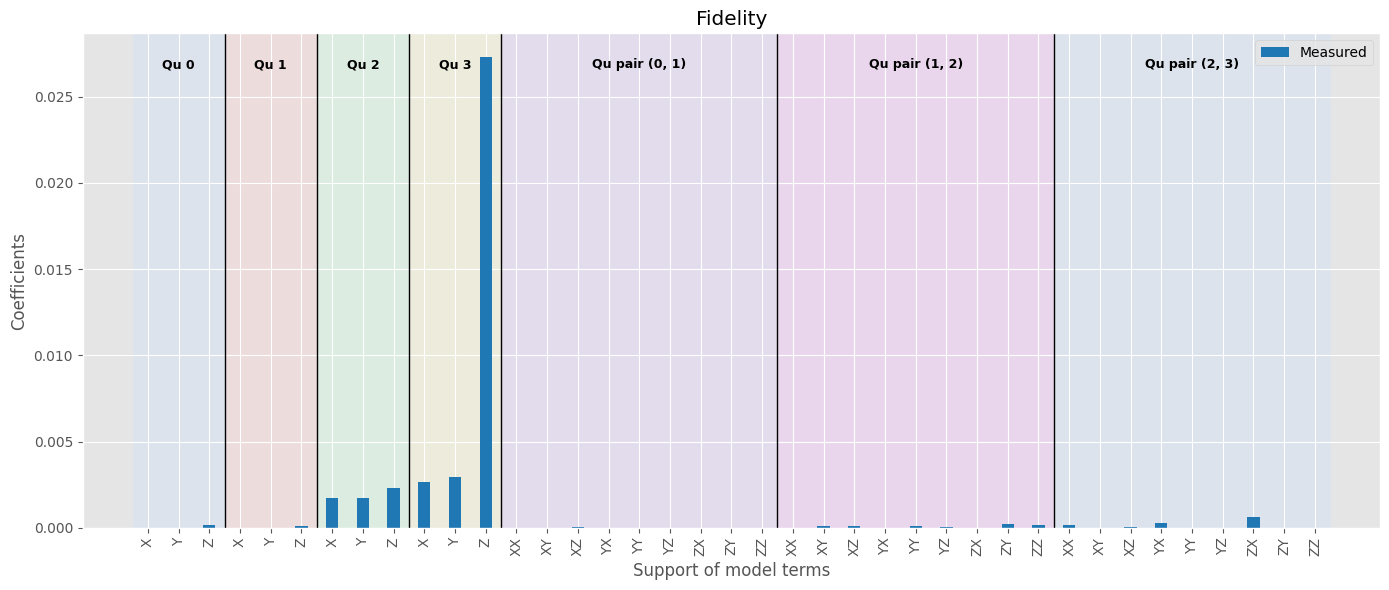

In [8]:
layer.plot_coeffs(plot_style = 2)

In [9]:
# 2. PER-Experiment Setup
perexp = experiment.create_per_experiment([qc])

perexp.generate(
    expectations=paulis,
    samples=500,
    noise_strengths=[0, 1, 2]
)

# 3. Ausführen
perexp.run(executor)

In [12]:
# 4. Analysieren
per_results = perexp.analyze()
result_1 = per_results[0].get_result(paulis[0]).plot()
print("Aus SV-Simulation: ",expectation_values[1])

KeyboardInterrupt: 

In [11]:
for k in range(len(paulis)):
    exact = expectation_values[k]
    calc = per_results[0].get_result(paulis[k]).get_expectations()[0]
    error = abs(abs(exact) - abs(calc)) / abs(exact)

    print(f"Relativer Fehler für {paulis[k]}: {error * 100:.2f}%")

    if error > 0.05:
        print(f"    → Exakter Wert:    {exact}")
        print(f"    → Berechneter Wert: {calc}")

Relativer Fehler für IIZZ: 1.15%
Relativer Fehler für IZZI: 99.96%
    → Exakter Wert:    0.8502567619616741
    → Berechneter Wert: -0.00032308920616973437
Relativer Fehler für ZZII: 99.86%
    → Exakter Wert:    0.8502567621551933
    → Berechneter Wert: -0.001208036674820494
Relativer Fehler für IIIX: 4.20%
Relativer Fehler für IIIZ: 0.97%
Relativer Fehler für IIXI: 4.58%
Relativer Fehler für IIZI: 5.29%
    → Exakter Wert:    -0.922093683348159
    → Berechneter Wert: -0.9708776031462859
Relativer Fehler für IXII: 160.37%
    → Exakter Wert:    -0.3869667126164747
    → Berechneter Wert: 1.0075522119739866
Relativer Fehler für IZII: 99.98%
    → Exakter Wert:    -0.9220936833481591
    → Berechneter Wert: -0.00015477070012107302
Relativer Fehler für XIII: 167.11%
    → Exakter Wert:    -0.3869667127045487
    → Berechneter Wert: 1.0336219275820515
Relativer Fehler für ZIII: 99.78%
    → Exakter Wert:    -0.9220936835580283
    → Berechneter Wert: 0.002035123363273784
